## 1. Kütüphaneler ve veriyi yükleme

In [81]:
import sys
import subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pandas", "numpy", "matplotlib","scikit-learn"])


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip3.12 install --upgrade pip


0

In [92]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
warnings.filterwarnings("ignore")

DATA_PATH = Path("data/data.csv")
df = pd.read_csv(DATA_PATH)

## 2. Veri özeti

In [93]:
print(f"Satır: {len(df)}, Sütun: {len(df.columns)}")
df.head()

Satır: 569, Sütun: 33


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [102]:
df.dtypes

id                           int64
diagnosis                      str
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
concavity_worst     

## 3. Eksik değer kontrolü

In [110]:
df = df.drop(columns=[c for c in df.columns if str(c).startswith("Unnamed")], errors="ignore")
eksik_satirlar = df[df.isnull().any(axis=1)]
print(eksik_satirlar)
df = df.dropna()

Empty DataFrame
Columns: [id, diagnosis, radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, compactness_mean, concavity_mean, concave points_mean, symmetry_mean, fractal_dimension_mean, radius_se, texture_se, perimeter_se, area_se, smoothness_se, compactness_se, concavity_se, concave points_se, symmetry_se, fractal_dimension_se, radius_worst, texture_worst, perimeter_worst, area_worst, smoothness_worst, compactness_worst, concavity_worst, concave points_worst, symmetry_worst, fractal_dimension_worst]
Index: []

[0 rows x 32 columns]


## 4. Tip tutarlılığı 

In [117]:
sayisal_ozellik = [c for c in df.columns if c not in ("id", "diagnosis") and not str(c).startswith("Unnamed")]
tip_sorunlari = []
for col in df.select_dtypes(include="object").columns:
    if col == "diagnosis":
        continue
    sayi = pd.to_numeric(df[col], errors="coerce")
    gecersiz = df.loc[sayi.isna() & df[col].notna(), col]
    if len(gecersiz) > 0:
        tip_sorunlari.append((col, gecersiz.unique()[:5].tolist(), len(gecersiz)))

if not tip_sorunlari:
    print("Sayısal sütunlarda string/geçersiz değer yok.")
else:
    for col, ornekler, adet in tip_sorunlari:
        print(f"{col}: {adet} geçersiz, örnek: {ornekler}")
print(f"diagnosis: {df['diagnosis'].unique().tolist()}")

Sayısal sütunlarda string/geçersiz değer yok.
diagnosis: ['M', 'B']


### Y'yi etkileyen sütunlar (Y ile korelasyon)

High impact on Y (15): ['concave points_worst', 'perimeter_worst', 'concave points_mean', 'radius_worst', 'perimeter_mean', 'area_worst', 'radius_mean', 'area_mean'] ...
Low impact on Y (15): ['texture_worst', 'smoothness_worst', 'symmetry_worst', 'texture_mean', 'concave points_se', 'smoothness_mean', 'symmetry_mean', 'fractal_dimension_worst'] ...


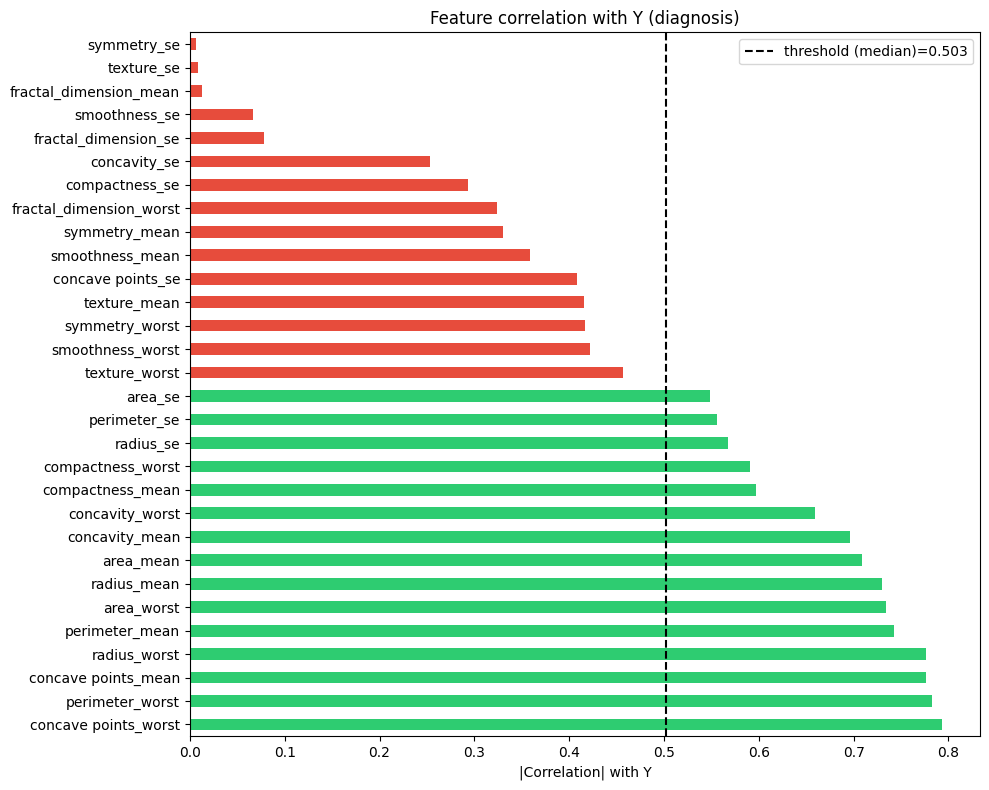

In [123]:
X = df[sayisal_ozellik].copy()
y = df["diagnosis"].replace({"B": 0, "M": 1}).astype(int)

corr_with_y = X.corrwith(y).abs().sort_values(ascending=False)
threshold = corr_with_y.median()
high_impact = corr_with_y[corr_with_y >= threshold].index.tolist()
low_impact = corr_with_y[corr_with_y < threshold].index.tolist()
print(f"High impact on Y ({len(high_impact)}):", high_impact[:8], "..." if len(high_impact) > 8 else "")
print(f"Low impact on Y ({len(low_impact)}):", low_impact[:8], "..." if len(low_impact) > 8 else "")

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#2ecc71" if v >= threshold else "#e74c3c" for v in corr_with_y.values]
corr_with_y.plot(kind="barh", ax=ax, color=colors)
ax.axvline(threshold, color="black", linestyle="--", label=f"threshold (median)={threshold:.3f}")
ax.set_xlabel("|Correlation| with Y")
ax.set_title("Feature correlation with Y (diagnosis)")
ax.legend()
plt.tight_layout()
Path("report_figures").mkdir(exist_ok=True)
plt.savefig("report_figures/01_correlation_with_y.png", dpi=150)
plt.show()

### Aykırı değer (sadece eşik üstü sütunlar – IQR)

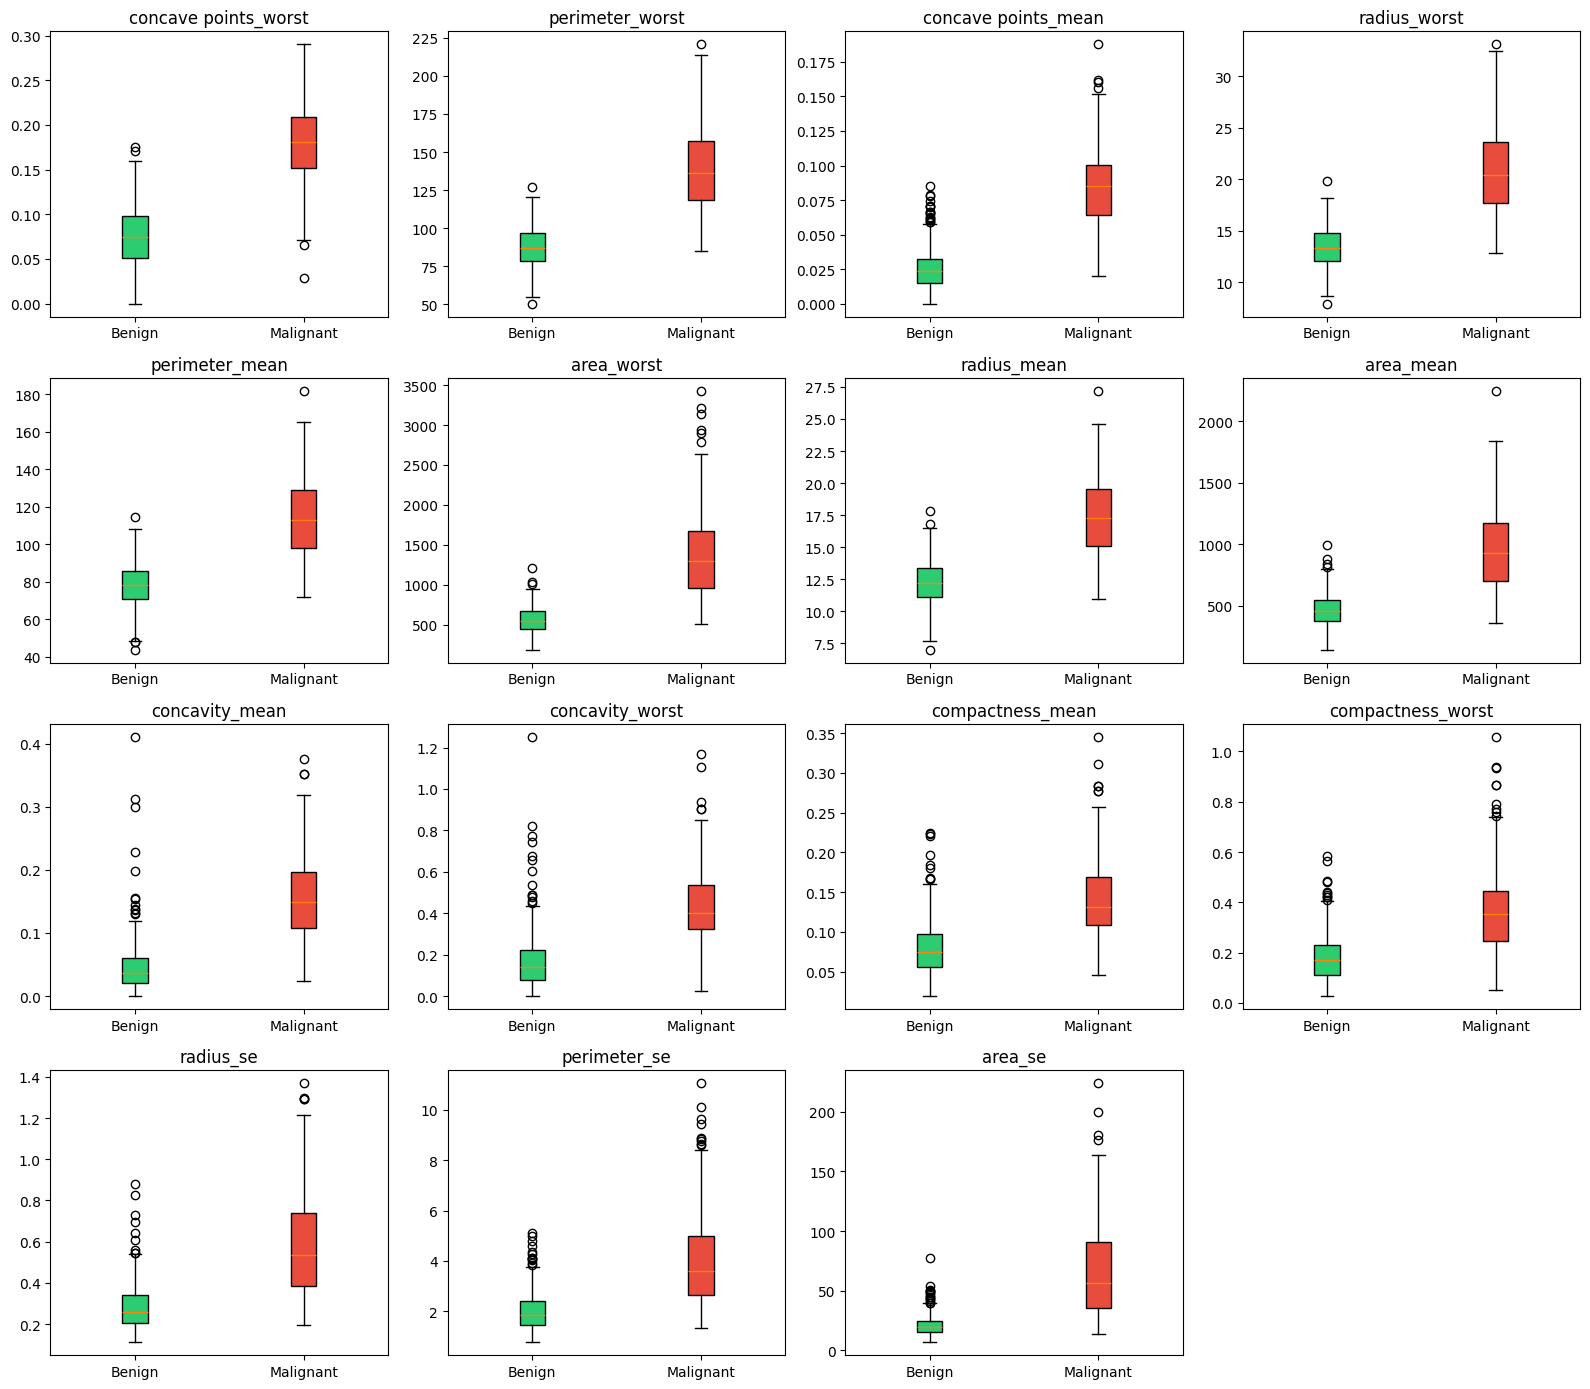

In [128]:
plot_df = X[high_impact].copy()
plot_df["diagnosis"] = df["diagnosis"].map({"B": "Benign", "M": "Malignant"})

n_cols = 4
n_rows = (len(high_impact) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.5 * n_rows))
axes = np.atleast_1d(axes).flatten()

for i, col in enumerate(high_impact):
    ax = axes[i]
    data_benign = plot_df.loc[plot_df["diagnosis"] == "Benign", col]
    data_malignant = plot_df.loc[plot_df["diagnosis"] == "Malignant", col]
    bp = ax.boxplot(
        [data_benign, data_malignant],
        labels=["Benign", "Malignant"],
        patch_artist=True,
        showfliers=True,
    )
    bp["boxes"][0].set_facecolor("#2ecc71")
    bp["boxes"][1].set_facecolor("#e74c3c")
    ax.set_title(col)
    ax.set_ylabel("")

for j in range(len(high_impact), len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
Path("report_figures").mkdir(exist_ok=True)
plt.savefig("report_figures/02_boxplot_high_impact.png", dpi=150)
plt.show()

## Aykırı değerler – satır bazında (IQR)

Sütun atmıyoruz: Her **satır** için, **kaç sütunda** aykırı değer var ona bakıyoruz. Bir satırı çıkarmayı sadece birden fazla sütunda aykırı olduğunda düşünürüz (tek sütundaki aykırılık yeterli değil).

In [ ]:
cols_for_outlier = [c for c in high_impact if c in X.columns]
X_numeric = X[cols_for_outlier].copy()
print(f"Aykırılık bakılan sütunlar – eşik üstü ({len(X_numeric.columns)} adet): {X_numeric.columns.tolist()}\n")

def iqr_outlier_mask(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    if pd.isna(IQR) or IQR == 0:
        return pd.Series(False, index=series.index)
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    mask = (series < lower) | (series > upper)
    return mask.fillna(False)

# Satır bazında: her satırda kaç sütunda (eşik üstü sütunlarda) aykırı var?
outlier_per_col = X_numeric.apply(iqr_outlier_mask)
outlier_count_per_row = outlier_per_col.sum(axis=1).fillna(0).astype(int)

# 7'den fazla aykırı değeri olan satırları uçur
MAX_OUTLIERS_PER_ROW = 6
keep_mask = outlier_count_per_row <= MAX_OUTLIERS_PER_ROW
dropped_mask = ~keep_mask
dropped_indices = dropped_mask[dropped_mask].index.tolist()
n_dropped = len(dropped_indices)

# X ve y'yi güncelle; kalan satırlar için aykırı sayısını da güncelle
X = X.loc[keep_mask].copy()
y = y.loc[X.index]
outlier_count_per_row = outlier_count_per_row.loc[X.index]

print(f"7'den fazla aykırı değeri olan {n_dropped} satır çıkarıldı. Kalan: {len(X)} satır.")
print(f"Çıkarılan satır indeksleri: {dropped_indices}")



Aykırılık bakılan sütunlar – eşik üstü (15 adet): ['concave points_worst', 'perimeter_worst', 'concave points_mean', 'radius_worst', 'perimeter_mean', 'area_worst', 'radius_mean', 'area_mean', 'concavity_mean', 'concavity_worst', 'compactness_mean', 'compactness_worst', 'radius_se', 'perimeter_se', 'area_se']

7'den fazla aykırı değeri olan 5 satır çıkarıldı. Kalan: 555 satır.
Çıkarılan satır indeksleri: [0, 236, 272, 339, 503]


## 7. Train/Test split ve ölçekleme

In [138]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]} samples, Test: {X_test.shape[0]} samples")

Train: 444 samples, Test: 111 samples


## 8. Logistic Regression

Scaled veri üzerinde logistic regression ile sınıflandırma denemesi.

In [140]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {acc:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["B", "M"]))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Test Accuracy: 0.9730

Classification Report:
              precision    recall  f1-score   support

           B       0.97      0.99      0.98        71
           M       0.97      0.95      0.96        40

    accuracy                           0.97       111
   macro avg       0.97      0.97      0.97       111
weighted avg       0.97      0.97      0.97       111

Confusion Matrix:
[[70  1]
 [ 2 38]]


## 9. Diğer modeller (karşılaştırma)

Aynı train/test ve scaled veri ile birkaç model deneyip accuracy karşılaştırması.

In [142]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "SVM (RBF)": SVC(kernel="rbf", random_state=42),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
}

results = []
predictions = {}
test_indices = X_test.index

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    predictions[name] = pred
    acc = accuracy_score(y_test, pred)
    n_wrong = (pred != y_test.values).sum()
    results.append((name, acc, n_wrong))

results_df = pd.DataFrame(results, columns=["Model", "Test Accuracy", "Yanlış sayısı"])
results_df = results_df.sort_values("Test Accuracy", ascending=False)
print(results_df.to_string(index=False))

# Aynı accuracy = aynı örnekleri mi yanlış yapıyor? Bakalım.
print("\n--- Hangi modeller aynı örnekleri yanlış yapıyor? ---")
wrong_indices = {}
for name, pred in predictions.items():
    wrong = test_indices[pred != y_test.values].tolist()
    wrong_indices[name] = set(wrong)
    print(f"{name}: yanlış indeksler = {wrong}")

# Aynı hataları yapan modeller
from itertools import combinations
for (a, b) in combinations(wrong_indices.keys(), 2):
    if wrong_indices[a] == wrong_indices[b]:
        print(f"\n→ {a} ve {b} tamamen aynı {len(wrong_indices[a])} örnekte hata yapıyor.")

              Model  Test Accuracy  Yanlış sayısı
Logistic Regression       0.972973              3
      Random Forest       0.972973              3
          SVM (RBF)       0.972973              3
          KNN (k=5)       0.963964              4
  Gradient Boosting       0.954955              5

--- Hangi modeller aynı örnekleri yanlış yapıyor? ---
Logistic Regression: yanlış indeksler = [40, 215, 455]
Random Forest: yanlış indeksler = [40, 126, 86]
Gradient Boosting: yanlış indeksler = [40, 126, 193, 86, 205]
SVM (RBF): yanlış indeksler = [40, 215, 99]
KNN (k=5): yanlış indeksler = [91, 40, 99, 205]
